In [1]:
import sys
from pathlib import Path

root = Path().resolve().parent  # ../ from notebooks/
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

In [3]:
from engines.monte_carlo import MonteCarloPricing
from models.black_scholes import OptionPrice
from unittest.mock import patch
import numpy as np
import matplotlib.pyplot as plt

# Initial Monte Carlo Pricing
Pricing of European and American Puts and Calls

In [3]:
from engines.monte_carlo import *
mc = MonteCarloPricing(S_0=100, X=100, r=0.05, sigma=0.2, T=1.0, num_paths=100000, steps=252, seed=10)

price_e, stderr_e = mc.european(call=True, antithetic=True)
print(f"EU Call Price {price_e:.4f} ± {1.96*stderr_e:.4f} (95% CI)")

price_a, stderr_a = mc.american(call=True, antithetic=True, basis_fn="laguerre")
print(f"US Call Price {price_a:.4f} ± {1.96*stderr_a:.4f} (95% CI)")

price_e, stderr_e = mc.european(call=False, antithetic=True)
print(f"EU Put Price {price_e:.4f} ± {1.96*stderr_e:.4f} (95% CI)")

price_a, stderr_a = mc.american(call=False, antithetic=True)
print(f"US Put Price {price_a:.4f} ± {1.96*stderr_a:.4f} (95% CI)")

EU Call Price 10.3868 ± 0.0908 (95% CI)
US Call Price 9.8833 ± 0.0736 (95% CI)
EU Put Price 5.5310 ± 0.0534 (95% CI)
US Put Price 5.9802 ± 0.0384 (95% CI)


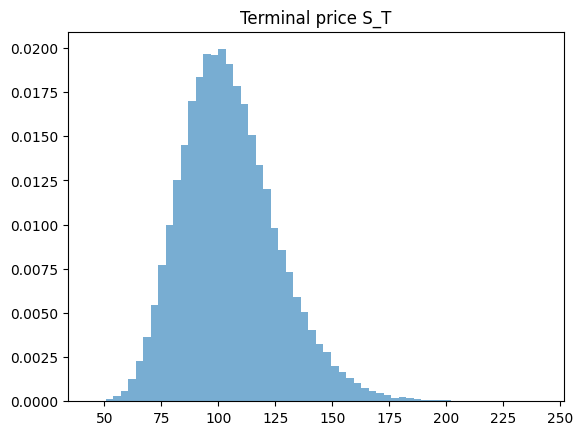

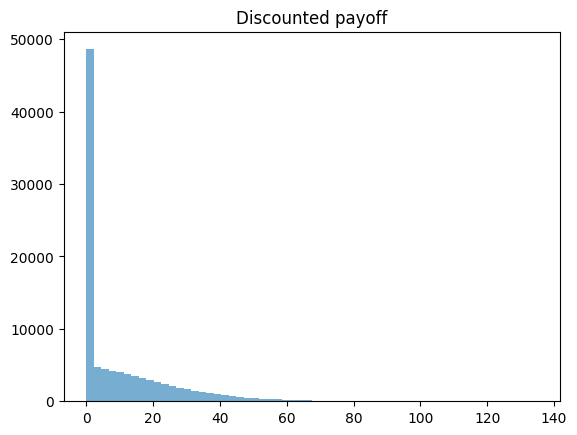

In [4]:
import matplotlib.pyplot as plt, numpy as np
paths = mc.simulate_paths()
S_T = paths[-1]
plt.hist(S_T, bins=60, density=True, alpha=0.6); plt.title("Terminal price S_T"); plt.show()

payoff = np.maximum(S_T - mc.X, 0.0)  # call
disc = np.exp(-mc.r * mc.T) * payoff
plt.hist(disc, bins=60, alpha=0.6); plt.title("Discounted payoff"); plt.show()

Reference American Call Price: 6.0029


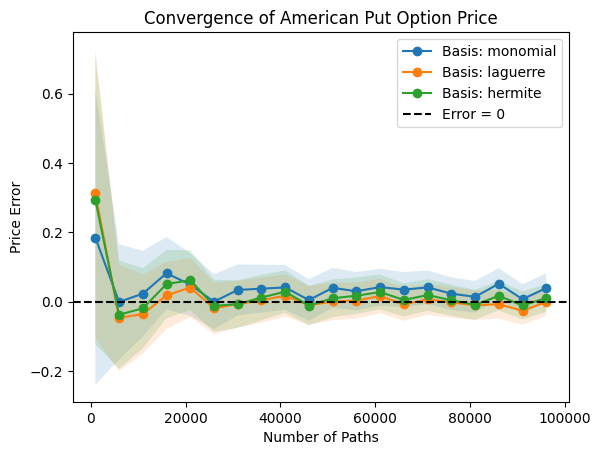

In [5]:
import numpy as np, matplotlib.pyplot as plt
sizes = np.arange(1000, 101000, 5000)
bases = ['monomial', 'laguerre', 'hermite']
seed = 42
prices, errs = [], []

reference_mc = MonteCarloPricing(100, 100, 0.2, 1.0, r=0.05, num_paths=1_000_000, steps=252, seed=seed)
ref_price, _ = reference_mc.american(call=False, antithetic=True, basis_fn='laguerre')
print(f"Reference American Call Price: {ref_price:.4f}")

plt.figure()
for basis in bases:
    prices = []
    errs = []

    for n in sizes:
        mc_n = MonteCarloPricing(100, 100, 0.2, 1.0, r=0.05, num_paths=n, steps=252, seed=seed)
        p, se = mc_n.american(call=False, antithetic=True, basis_fn=basis)
        prices.append(p)
        errs.append(se)

    prices = np.array(prices)
    errs  = np.array(errs)

    plt.plot(sizes, prices - ref_price, marker='o', label=f'Basis: {basis}')
    plt.fill_between(sizes, prices - ref_price - 1.96 * errs, prices - ref_price + 1.96 * errs, alpha=0.15)

plt.axhline(0.0, color='k', linestyle='--', label='Error = 0')
plt.xlabel('Number of Paths')
plt.ylabel('Price Error')
plt.title('Convergence of American Put Option Price')
plt.legend()
plt.show()

In [6]:
import numpy as np
S = mc._simulate_paths(antithetic=False); S_T = S[-1]
disc_no = np.exp(-mc.r*mc.T) * np.maximum(S_T - mc.X, 0.0)
S = mc._simulate_paths(antithetic=True); S_T = S[-1]
disc_an = np.exp(-mc.r*mc.T) * np.maximum(S_T - mc.X, 0.0)
print("Standard Deviation No Antithetic:", disc_no.std(), "Standard Deviation Antithetic:", disc_an.std())

Standard Deviation No Antithetic: 14.662130437777895 Standard Deviation Antithetic: 14.649846320057067


American put (binomial, 2000 steps): 6.0900
American put (LSM MC, 200000 paths):   6.0008 ± 0.0273  (95% CI)


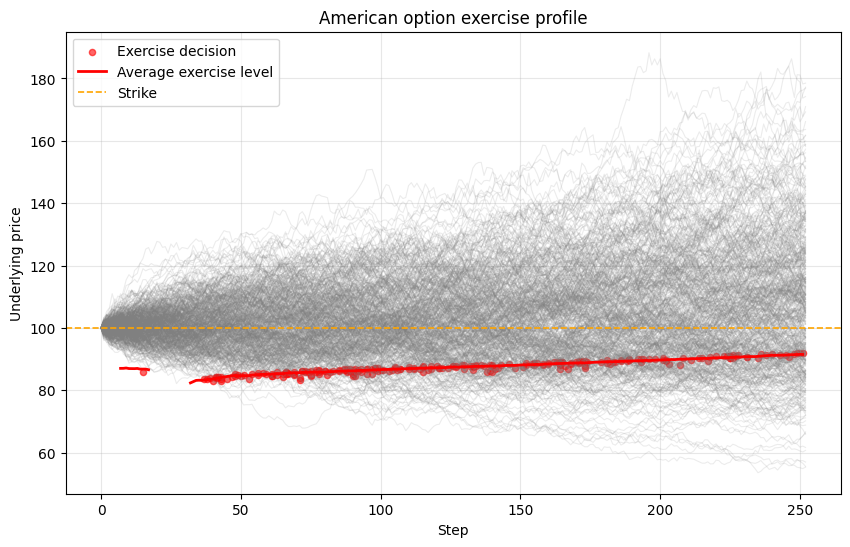

In [5]:
from models.binomial_method import BinomialPricing

S0    = 100.0
K     = 100.0
r     = 0.05
sigma = 0.20
T     = 1.0   # years

# High-resolution binomial tree as "reference" American price
steps_tree = 2000
binom = BinomialPricing(S_0=S0, K=K, r=r, sigma=sigma, T=T, steps=steps_tree)
price_binom = binom.american(call=False)  # American put

# Longstaff–Schwartz Monte Carlo check
mc_paths = 200_000
mc_steps = 252
mc = MonteCarloPricing(S_0=S0, X=K, sigma=sigma, T=T, r=r,
                       num_paths=mc_paths, steps=mc_steps, seed=123)
price_mc, se_mc = mc.american(call=False, basis_fn="laguerre", antithetic=True)

print(f"American put (binomial, {steps_tree} steps): {price_binom:.4f}")
print(f"American put (LSM MC, {mc_paths} paths):   {price_mc:.4f} ± {1.96*se_mc:.4f}  (95% CI)")

price_us, stderr_us = mc.plot_american_exercise(call=False, basis_fn='hermite', antithetic=True,
                                                   show_boundary=True)


# Quasi-Monte Carlo
Using Sobol' sequences and Brownian Bridge rather than regular pseudo-random numbers. Still have antithetic variates.

In [ ]:
from models.black_scholes import OptionPrice
from engines.monte_carlo import MonteCarloPricing
from engines.qmc import QuasiMonteCarloPricing

S0, K, sigma, T, r = 100.0, 100.0, 0.2, 1.0, 0.05
paths, steps = 4096, 252

black_scholes = OptionPrice(S0, K, T, r, sigma)
pseudo = MonteCarloPricing(S0, K, sigma, T, r=r, num_paths=paths, steps=steps, seed=123)
quasi = QuasiMonteCarloPricing(S0, K, sigma, T, r=r, num_paths=paths, steps=steps,
                               seed=123, brownian_bridge=True)

price_bs = black_scholes.call()
price_mc, err_mc = pseudo.european(call=True, antithetic=True)
price_qmc, err_qmc = quasi.european(call=True, antithetic=True)

print(f"Black-Scholes Price: {price_bs:.4f}")
print(f"Pseudo MC  : {price_mc:.4f} ± {err_mc:.4f}")
print(f"Quasi MC   : {price_qmc:.4f} ± {err_qmc:.4f}")


Black-Scholes Price: 18.1269
Pseudo MC  : 10.6720 ± 0.2329
Quasi MC   : 10.4507 ± 0.2300


# Finite Difference Approximation of Sensitivities
Finding the sensitivities using Central Difference Estimate of European Call Option (European for now as American options require further computation)

In [5]:
from mc_finite_difference import EuropeanFiniteDifference, AmericanFiniteDifference

mc = MonteCarloPricing(S_0=100, X=100, r=0.05, sigma=0.2, T=1.0, num_paths=10000, steps=252)
mc_fd = EuropeanFiniteDifference(pricer=mc, call=True, antithetic=True, S0_bump=1e-2, sigma_bump=1e-2, r_bump=1e-3)

price, stderr = mc_fd.price()
print(f"Price {price:.4f} ± {1.96*stderr:.4f} (95% CI)")

delta = mc_fd.delta()
vega = mc_fd.vega()
rho = mc_fd.rho()
print(f"Delta: {delta:.4f}")
print(f"Vega: {vega:.4f}")
print(f"Rho: {rho:.4f}")

TypeError: EuropeanFiniteDifference.__init__() got an unexpected keyword argument 'S0_bump'